# Model comparison — count MSE/MAE

Point `MODELS` at any number of trained weight files (e.g. picks from the sweep's `sweeps/v1/trials/<trial_id>/best.pt`, the hand-trained `runs/detect/train/weights/best.pt`, or the pretrained baseline). Each model is evaluated on the val split and the count-based metrics are plotted on top of each other so you can see which hyperparameters actually help.

Metrics are computed **per image** as `predicted_box_count − ground_truth_box_count` after thresholding on a confidence grid. The best confidence threshold per model is picked to minimise MSE.

Inference results are cached on disk (keyed by weights file mtime) so re-running with the same models is instant.

In [ ]:
# --- Config ---
# Baseline + always-on entries. The best sweep trial is auto-discovered below.
# Each sweep trial contributes its own training imgsz and best_conf, pulled
# from results.csv (so inference matches how the trial was scored).
BASE_MODELS = [
    ("Baseline YOLO",   "yolo26n.pt"),
    # ("hand-trained",    "runs/detect/train/weights/best.pt"),
]

SWEEP_DIR      = "sweeps/v5"           # sweep to pull the best trial from
SWEEP_TOP_K    = 1                      # number of top sweep trials to include

# Uses the new (4/16) val split — matches what sweep.py evaluates against.
DATA_YAML      = "data/manual_label_4_16_26/dataset.yaml"
BASELINE_IMGSZ = 1280        # imgsz used for BASE_MODELS entries (sweep trials bring their own)
DEVICE         = 0           # GPU index, or 'cpu'
PERSON_CLASS   = 0           # COCO person = class 0; fine-tuned runs also use 0
CONF_GRID      = [round(x * 0.01, 2) for x in range(10, 71, 5)]  # 0.10 .. 0.70
CACHE_DIR      = "runs/compare_cache"

# Pin a fixed conf threshold for specific models (skips MSE-minimization).
# Standard COCO inference uses 0.10 for the pretrained baseline. Sweep trials
# auto-populate this dict below with their training-time best_conf.
FIXED_CONF  = {"Baseline YOLO": 0.10}

# SAM3 raw predictions (pre-generated, no confidence scores — treated as conf=1.0).
# NOTE: data/manual_label_4_15_26/raw/labels is the *manually corrected* source,
# NOT SAM3 output. Real SAM3 predictions live in data/stream5/labels.
SAM3_LABELS_DIR = "data/stream5/labels"
SAM3_LABEL      = "SAM3"

# Which columns from results.csv to show in the per-trial hyperparam dump.
# Grouped to mirror sweep.py's config: identity → scores → training → aug.
HYPERPARAM_COLS = [
    # identity
    "trial_id", "model", "timestamp", "duration_sec",
    # scores
    "count_mse", "count_mae", "best_conf", "mAP50", "n_val_images",
    # core training
    "imgsz", "batch", "optimizer", "lr0", "lrf", "momentum",
    "weight_decay", "warmup_epochs", "cos_lr", "dropout",
    # loss weights
    "box", "cls", "dfl",
    # augmentations
    "hsv_h", "hsv_s", "hsv_v", "degrees", "translate", "scale",
    "fliplr", "flipud", "mosaic", "mixup", "copy_paste", "erasing",
    "close_mosaic",
]

import csv
from pathlib import Path
import hashlib, pickle, os, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yaml

CACHE_DIR = Path(CACHE_DIR)
CACHE_DIR.mkdir(parents=True, exist_ok=True)


def discover_best_sweep_models(sweep_dir: str, k: int = 1):
    """Read sweep results.csv and return
    [(label, weight_path, imgsz, best_conf, row_dict)] for the top-K trials by
    count_mse whose best.pt still exists on disk."""
    sweep = Path(sweep_dir)
    csv_path = sweep / "results.csv"
    if not csv_path.exists():
        print(f"  (no sweep results at {csv_path})")
        return []
    rows = []
    with csv_path.open() as f:
        for r in csv.DictReader(f):
            if r.get("status") != "ok":
                continue
            try:
                rows.append((float(r["count_mse"]), r["trial_id"], r))
            except (KeyError, ValueError, TypeError):
                continue
    rows.sort(key=lambda x: x[0])
    picked = []
    for mse, tid, r in rows:
        if len(picked) >= k:
            break
        w = sweep / "trials" / tid / "best.pt"
        if not w.exists():
            continue
        model_name = r.get("model", "?")
        imgsz = int(float(r["imgsz"])) if r.get("imgsz") else BASELINE_IMGSZ
        try:
            best_conf = float(r["best_conf"])
        except (KeyError, ValueError, TypeError):
            best_conf = None
        suffix = "" if len(picked) == 0 else f" #{len(picked)+1}"
        label = f"Finetuned YOLO{suffix}"
        picked.append((label, str(w), imgsz, best_conf, r))
    return picked


def print_hyperparams(label: str, row: dict, weights_path: str):
    """Pretty-print the full hyperparam row for a sweep trial."""
    print("=" * 78)
    print(f"{label}")
    print(f"  weights: {weights_path}")
    print("-" * 78)
    # Group by section for readability. `HYPERPARAM_COLS` is ordered already.
    pad = max(len(k) for k in HYPERPARAM_COLS if k in row) + 2
    for key in HYPERPARAM_COLS:
        if key not in row:
            continue
        val = row[key]
        # Try to format numeric values sensibly without losing precision.
        if isinstance(val, str):
            try:
                f = float(val)
                if f.is_integer() and "." not in val:
                    val_str = str(int(f))
                else:
                    val_str = f"{f:g}"
            except ValueError:
                val_str = val
        else:
            val_str = str(val)
        print(f"  {key:<{pad}}{val_str}")
    print("=" * 78)


# Merge baseline + sweep picks into a uniform (label, weights, imgsz) layout,
# auto-pinning each sweep trial's training-time best_conf into FIXED_CONF.
MODELS = [(lbl, w, BASELINE_IMGSZ) for (lbl, w) in BASE_MODELS]
sweep_picks = discover_best_sweep_models(SWEEP_DIR, SWEEP_TOP_K)
for label, w, imgsz, best_conf, _row in sweep_picks:
    MODELS.append((label, w, imgsz))
    if best_conf is not None:
        FIXED_CONF[label] = best_conf

# Resolve & validate every model's weight path up front.
models_resolved = []  # list of (label, path, imgsz)
for label, w, imgsz in MODELS:
    p = Path(w).resolve()
    if not p.exists():
        print(f"SKIP  {label!r}: weights not found at {p}")
        continue
    models_resolved.append((label, p, imgsz))
print(f"{len(models_resolved)} model(s) ready:")
for label, p, imgsz in models_resolved:
    pinned = f"  conf={FIXED_CONF[label]}" if label in FIXED_CONF else ""
    print(f"  {label:40s}  imgsz={imgsz}{pinned}  {p}")

# Dump full hyperparams for every selected sweep trial (in rank order).
if sweep_picks:
    print()
    print(f"Top {len(sweep_picks)} sweep trial hyperparameters (from {SWEEP_DIR}/results.csv):")
    for label, w, _imgsz, _bc, row in sweep_picks:
        print_hyperparams(label, row, w)

sam3_dir = Path(SAM3_LABELS_DIR).resolve()
if sam3_dir.is_dir():
    print(f"SAM3 labels dir: {sam3_dir}  ({sum(1 for _ in sam3_dir.glob('*.txt'))} .txt files)")
else:
    print(f"SAM3 labels dir NOT FOUND at {sam3_dir} — it will be skipped")

In [ ]:
# --- Load val images + ground-truth counts ---
IMG_EXT = {".jpg", ".jpeg", ".png"}

with open(DATA_YAML) as f:
    data_cfg = yaml.safe_load(f)
val_dir = Path(data_cfg["path"]) / data_cfg["val"]
val_lbl_dir = Path(str(val_dir).replace("/images/", "/labels/"))

val_images = sorted(p for p in val_dir.iterdir() if p.suffix.lower() in IMG_EXT)
gt_counts = []
for p in val_images:
    lbl = val_lbl_dir / f"{p.stem}.txt"
    if lbl.exists():
        n = sum(1 for line in lbl.read_text().splitlines() if line.strip())
    else:
        n = 0
    gt_counts.append(n)
gt_counts = np.array(gt_counts, dtype=np.float64)

print(f"Val split: {len(val_images)} images")
print(f"GT count per image: mean={gt_counts.mean():.2f}  min={gt_counts.min():.0f}  "
      f"max={gt_counts.max():.0f}  total={int(gt_counts.sum())}")

Val split: 51 images
GT count per image: mean=17.55  min=6  max=41  total=895


In [ ]:
# --- Run inference for each model (cached) ---
# We store one confidence score per predicted box per image at conf=0.001, so
# any threshold in CONF_GRID can be applied in post without re-running.
# Each model runs at its own imgsz (from the sweep trial's training config).
from ultralytics import YOLO

def cache_key(weights_path: Path, imgsz: int) -> Path:
    h = hashlib.md5()
    h.update(str(weights_path).encode())
    h.update(str(weights_path.stat().st_mtime_ns).encode())
    h.update(str(imgsz).encode())
    h.update(str(DATA_YAML).encode())
    return CACHE_DIR / f"{h.hexdigest()[:16]}.pkl"

def run_model(weights_path: Path, imgsz: int):
    ck = cache_key(weights_path, imgsz)
    if ck.exists():
        with open(ck, "rb") as f:
            return pickle.load(f)
    model = YOLO(str(weights_path))
    per_image_confs = []
    t0 = time.time()
    stream = model.predict(
        source=[str(p) for p in val_images],
        conf=0.001,
        imgsz=imgsz,
        device=DEVICE,
        classes=[PERSON_CLASS],
        verbose=False,
        stream=True,
    )
    for res in stream:
        if res.boxes is None or len(res.boxes) == 0:
            per_image_confs.append(np.zeros(0, dtype=np.float32))
        else:
            per_image_confs.append(res.boxes.conf.detach().cpu().numpy().astype(np.float32))
    payload = {"confs": per_image_confs, "imgsz": imgsz, "elapsed": time.time() - t0}
    with open(ck, "wb") as f:
        pickle.dump(payload, f)
    return payload

model_preds = {}
for label, p, imgsz in models_resolved:
    print(f"  running {label!r} (imgsz={imgsz}) ...", end=" ", flush=True)
    model_preds[label] = run_model(p, imgsz)
    print(f"done ({model_preds[label]['elapsed']:.1f}s)")


# --- SAM3 pseudo-predictions (static labels, no confidence) ---
# Treat each box in a SAM3 .txt as a prediction with conf=1.0, so any threshold
# in CONF_GRID keeps the full count. This shows up as a flat line on MSE-vs-conf.
def load_sam3_counts(lbl_dir: Path, img_paths):
    per_image_confs = []
    missing = 0
    for img in img_paths:
        lbl = lbl_dir / f"{img.stem}.txt"
        if not lbl.exists():
            missing += 1
            per_image_confs.append(np.zeros(0, dtype=np.float32))
            continue
        n = sum(1 for line in lbl.read_text().splitlines() if line.strip())
        per_image_confs.append(np.full(n, 1.0, dtype=np.float32))
    return per_image_confs, missing

if sam3_dir.is_dir():
    t0 = time.time()
    sam3_confs, missing = load_sam3_counts(sam3_dir, val_images)
    model_preds[SAM3_LABEL] = {"confs": sam3_confs, "imgsz": None, "elapsed": time.time() - t0}
    total = sum(len(c) for c in sam3_confs)
    print(f"  loaded {SAM3_LABEL!r}: {total} boxes across {len(val_images)} images"
          f"  (missing label files: {missing})")
else:
    print(f"  skipping {SAM3_LABEL!r}: {sam3_dir} not found")

In [ ]:
# --- Compute count MSE / MAE / bias across CONF_GRID for every model ---
rows = []
curves = {}  # label -> dict of arrays keyed by metric, indexed by CONF_GRID

def _nearest_conf_index(target: float) -> int:
    return int(np.argmin([abs(c - target) for c in CONF_GRID]))

for label, payload in model_preds.items():
    confs = payload["confs"]
    mse_arr, mae_arr, bias_arr = [], [], []
    for c in CONF_GRID:
        pred = np.array([(cf >= c).sum() for cf in confs], dtype=np.float64)
        err = pred - gt_counts
        mse_arr.append(float((err ** 2).mean()))
        mae_arr.append(float(np.abs(err).mean()))
        bias_arr.append(float(err.mean()))
    mse_arr = np.array(mse_arr); mae_arr = np.array(mae_arr); bias_arr = np.array(bias_arr)
    if label in FIXED_CONF:
        best_i = _nearest_conf_index(FIXED_CONF[label])
    else:
        best_i = int(np.argmin(mse_arr))
    curves[label] = {"mse": mse_arr, "mae": mae_arr, "bias": bias_arr}
    rows.append({
        "model": label,
        "best_conf": CONF_GRID[best_i],
        "conf_pinned": label in FIXED_CONF,
        "count_mse": mse_arr[best_i],
        "count_mae": mae_arr[best_i],
        "count_bias": bias_arr[best_i],
        "mse_at_0.25": mse_arr[CONF_GRID.index(0.25)] if 0.25 in CONF_GRID else np.nan,
    })

summary = pd.DataFrame(rows).sort_values("count_mse").reset_index(drop=True)
summary

,model,best_conf,conf_pinned,count_mse,count_mae,count_bias,mse_at_0.25
0,sweep#1 yolo26m.pt mse=3.13,0.15,False,14.470588,3.058824,-0.745098,32.176471
1,SAM3,0.10,False,39.490196,5.215686,5.215686,39.490196
2,baseline (coco),0.10,True,117.156863,8.686275,-8.294118,217.960784


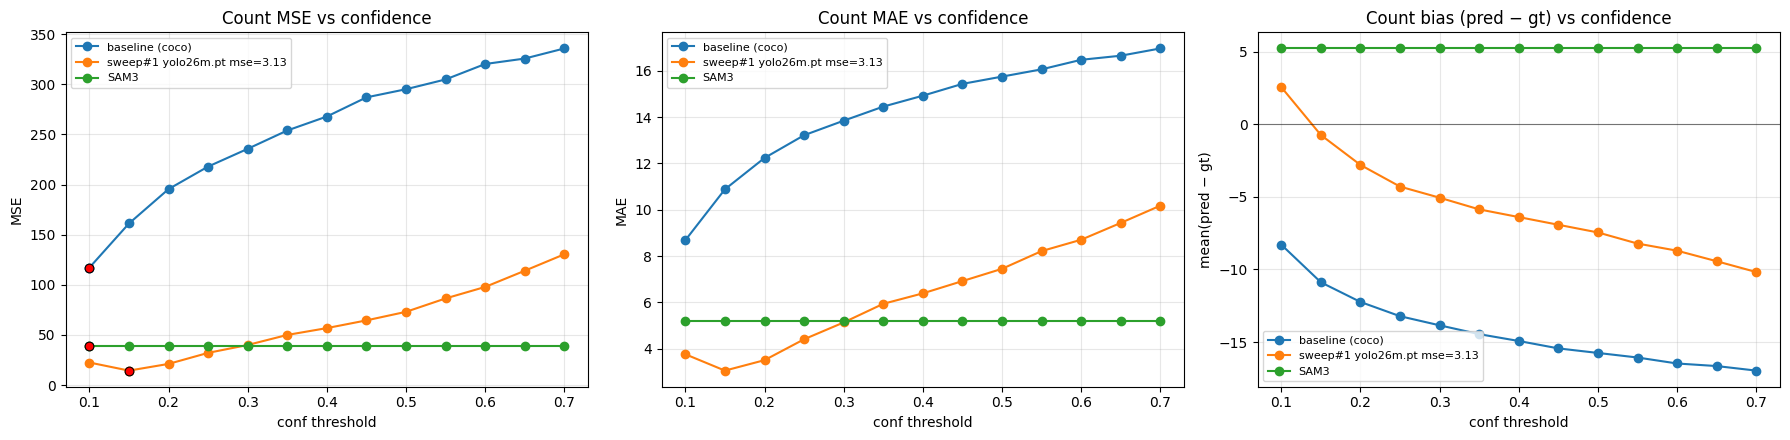

In [ ]:
# --- Plot: count metrics vs confidence threshold, one line per model ---
fig, axes = plt.subplots(1, 2, figsize=(18, 4.5))

for label, d in curves.items():
    axes[0].plot(CONF_GRID, d["mse"], marker="o", label=label)
    axes[1].plot(CONF_GRID, d["mae"], marker="o", label=label)
    axes[2].plot(CONF_GRID, d["bias"], marker="o", label=label)

# Mark each model's best-MSE threshold with a dot.
for label, d in curves.items():
    i = int(np.argmin(d["mse"]))
    axes[0].scatter(CONF_GRID[i], d["mse"][i], color="red", zorder=5, s=40,
                    edgecolor="black", linewidth=0.8)

axes[0].set_title("Count MSE vs confidence")
axes[0].set_xlabel("conf threshold"); axes[0].set_ylabel("MSE")
axes[0].grid(alpha=0.3); axes[0].legend(fontsize=8)

axes[1].set_title("Count MAE vs confidence")
axes[1].set_xlabel("conf threshold"); axes[1].set_ylabel("MAE")
axes[1].grid(alpha=0.3); axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

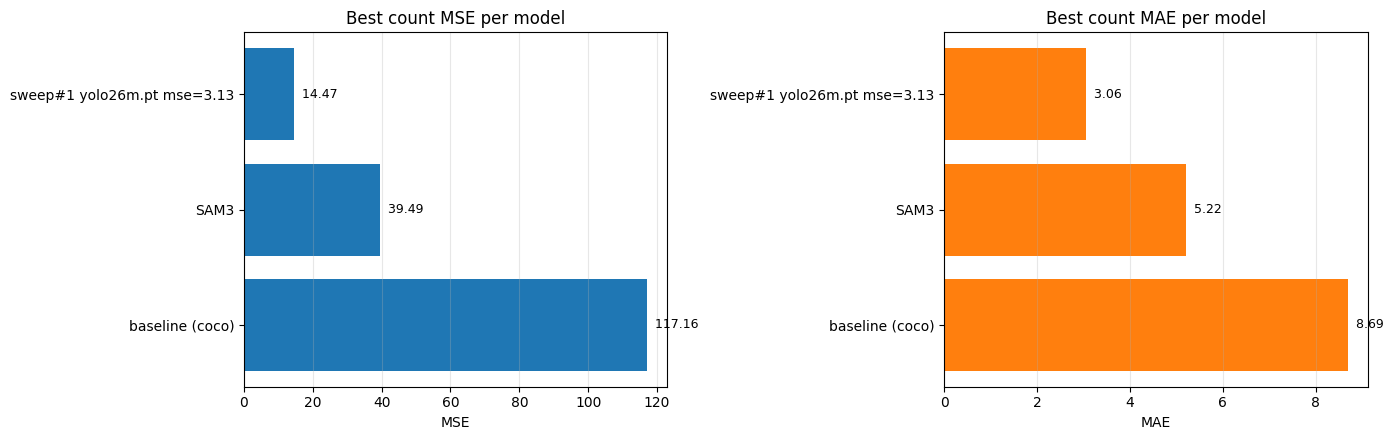

In [ ]:
# --- Bar chart: best count-MSE per model (ordered) ---
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

ordered = summary.sort_values("count_mse")
axes[0].barh(ordered["model"], ordered["count_mse"], color="tab:blue")
axes[0].invert_yaxis()
axes[0].set_title("Best count MSE per model")
axes[0].set_xlabel("MSE"); axes[0].grid(alpha=0.3, axis="x")
for i, (m, v) in enumerate(zip(ordered["model"], ordered["count_mse"])):
    axes[0].text(v, i, f"  {v:.2f}", va="center", fontsize=9)

ordered_mae = summary.sort_values("count_mae")
axes[1].barh(ordered_mae["model"], ordered_mae["count_mae"], color="tab:orange")
axes[1].invert_yaxis()
axes[1].set_title("Best count MAE per model")
axes[1].set_xlabel("MAE"); axes[1].grid(alpha=0.3, axis="x")
for i, (m, v) in enumerate(zip(ordered_mae["model"], ordered_mae["count_mae"])):
    axes[1].text(v, i, f"  {v:.2f}", va="center", fontsize=9)

plt.tight_layout()
plt.show()

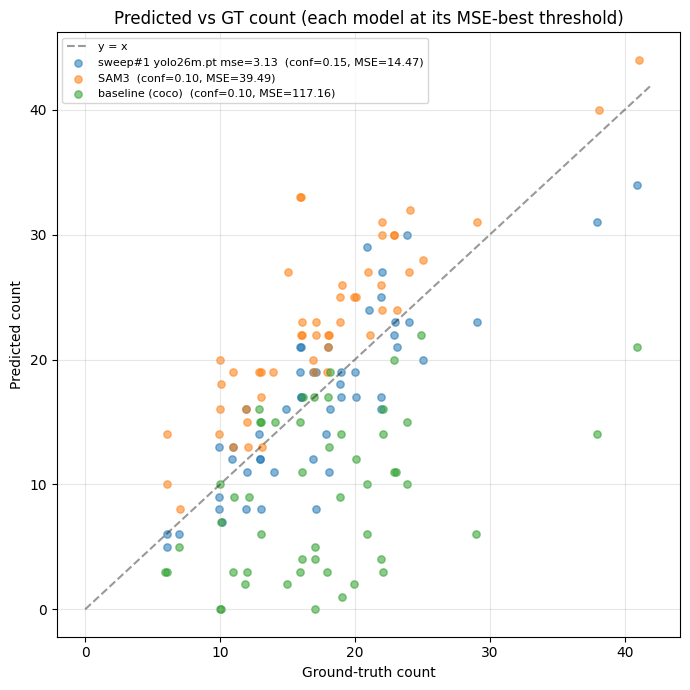

In [ ]:
# --- Predicted vs ground-truth count scatter (each model at its best conf) ---
fig, ax = plt.subplots(figsize=(7, 7))

lo, hi = 0, int(gt_counts.max()) + 1
ax.plot([lo, hi], [lo, hi], "k--", alpha=0.4, label="y = x")

for row in summary.itertuples():
    label = row.model
    best_c = row.best_conf
    confs = model_preds[label]["confs"]
    pred = np.array([(cf >= best_c).sum() for cf in confs], dtype=np.float64)
    # Jitter x a tiny bit so overlapping points are visible
    jitter = (np.random.default_rng(hash(label) & 0xFFFF).random(len(pred)) - 0.5) * 0.25
    ax.scatter(gt_counts + jitter, pred, alpha=0.55, s=28,
               label=f"{label}  (conf={best_c:.2f}, MSE={row.count_mse:.2f})")

ax.set_xlabel("Ground-truth count"); ax.set_ylabel("Predicted count")
ax.set_title("Predicted vs GT count (each model at its MSE-best threshold)")
ax.grid(alpha=0.3); ax.legend(fontsize=8, loc="upper left")
plt.tight_layout(); plt.show()

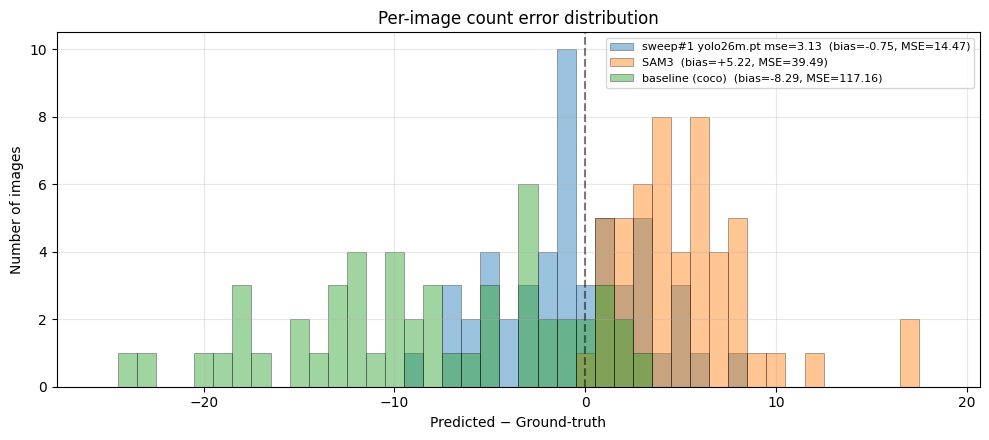

In [ ]:
# --- Error-distribution histogram per model (at each model's best conf) ---
fig, ax = plt.subplots(figsize=(10, 4.5))

all_errs = []
model_errs = {}
for row in summary.itertuples():
    confs = model_preds[row.model]["confs"]
    pred = np.array([(cf >= row.best_conf).sum() for cf in confs], dtype=np.float64)
    err = pred - gt_counts
    model_errs[row.model] = err
    all_errs.extend(err.tolist())

lo_b, hi_b = int(min(all_errs)) - 1, int(max(all_errs)) + 2
bins = np.arange(lo_b, hi_b + 1) - 0.5  # integer-centered bins

for label, err in model_errs.items():
    ax.hist(err, bins=bins, alpha=0.45,
            label=f"{label}  (bias={err.mean():+.2f}, MSE={(err**2).mean():.2f})",
            edgecolor="k", linewidth=0.5)

ax.axvline(0, color="k", linestyle="--", alpha=0.5)
ax.set_xlabel("Predicted − Ground-truth")
ax.set_ylabel("Number of images")
ax.set_title("Per-image count error distribution")
ax.grid(alpha=0.3); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

In [ ]:
# --- Sweep leaderboard (top 20 trials by count_mse) ---
# Useful for deciding whether to increase SWEEP_TOP_K above.
sweep_csv = Path(SWEEP_DIR) / "results.csv"
if sweep_csv.exists():
    leaderboard = pd.read_csv(sweep_csv)
    leaderboard = leaderboard[leaderboard["status"] == "ok"]
    leaderboard = leaderboard.sort_values("count_mse").head(20).reset_index(drop=True)
    # Keep only the columns most useful for picking a model
    show_cols = [c for c in [
        "trial_id", "model", "imgsz", "batch", "optimizer", "lr0",
        "count_mse", "count_mae", "best_conf", "mAP50", "duration_sec",
    ] if c in leaderboard.columns]
    display(leaderboard[show_cols])
else:
    print(f"No sweep results at {sweep_csv}")

,trial_id,model,imgsz,batch,optimizer,lr0,count_mse,count_mae,best_conf,mAP50,duration_sec
0,1776367331040_w0_0002,yolo26m.pt,1280,8,AdamW,0.0030,3.131868,1.373626,0.30,0.903591,424.83
1,1776369425307_w1_0012,yolo26s.pt,1280,16,SGD,0.0100,3.164835,1.318681,0.30,0.892861,219.44
2,1776367582142_w1_0005,yolo26m.pt,960,8,auto,0.0001,3.461538,1.439560,0.30,0.896079,240.16
3,1776367756415_w0_0003,yolo26m.pt,960,8,AdamW,0.0010,3.681319,1.351648,0.30,0.893948,255.12
4,1776370202965_w1_0017,yolo26m.pt,960,16,SGD,0.0100,3.725275,1.461538,0.30,0.904289,234.43
5,1776369031947_w1_0011,yolo26m.pt,1280,8,AdamW,0.0010,3.901099,1.549451,0.25,0.913050,392.88
6,1776366883818_w0_0001,yolo26m.pt,1280,16,SGD,0.0030,3.912088,1.560440,0.25,0.911777,446.62
7,1776368180100_w1_0008,yolo26m.pt,960,16,SGD,0.0030,3.956044,1.582418,0.25,0.896088,289.59
8,1776367111895_w1_0002,yolo26s.pt,960,16,auto,0.0100,3.956044,1.494505,0.25,0.886202,134.74
9,1776369867228_w1_0015,yolo26s.pt,960,16,SGD,0.0100,3.989011,1.549451,0.30,0.891220,125.90
